In [1]:
# basics libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters

# Libraries for maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Units libraries
import metpy.calc as mpcalc
from metpy.units import units

# Time libraries
import matplotlib.dates as mdates

# For metocean statistics
from metocean_stats import plots, tables

# Plots libraries
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.colors as colors
from matplotlib.lines import Line2D

Dataset used for latitude, longitude definition

In [2]:
ds_0 = xr.open_dataset("C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Maps_diff//hs_mean_diff01.nc", engine="h5netcdf")
ds_0

<xarray.Dataset> Size: 16MB
Dimensions:    (time: 1, bnds: 2, latitude: 787, longitude: 1651)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 8B 2020-01-16T11:30:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16B ...
    diff       (time, latitude, longitude) float32 5MB ...
Attributes: (12/22)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    product_name:                     ww3.run_with_currents202001.nc
    ...                               ...
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...
    history:                          Thu Oct  9 13:26:05 2025: ncks -A lan_l...
    history_of_appended_files:        Thu Oct  9 13:26:05 2025: Appended file...
    NCO:                              "4.5.2"

Bathymetry dataset

In [3]:
ds_bathy = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Grid//MED36_bathy_meter.nc", engine="scipy")
ds_bathy

<xarray.Dataset> Size: 16MB
Dimensions:     (Y: 787, X: 1651)
Coordinates:
  * X           (X) int32 7kB 1 2 3 4 5 6 7 ... 1646 1647 1648 1649 1650 1651
  * Y           (Y) int32 3kB 1 2 3 4 5 6 7 8 ... 781 782 783 784 785 786 787
Data variables:
    nav_lon     (Y, X) float32 5MB ...
    nav_lat     (Y, X) float32 5MB ...
    Bathymetry  (Y, X) float32 5MB ...
Attributes:
    Conventions:    CF-1.5
    Grid:           ARAKAWA-C
    Created_by:     SIREN create_bathy
    Creation_date:  2017-01-19 13:00:32
    periodicity:    0.0
    history:        Tue Mar  7 14:42:16 2017: ncrename -d x,X -d y,Y test.nc....

In [4]:
ds_bathy = ds_bathy.rename({"Y": "latitude", "X": "longitude"})
ds_bathy

<xarray.Dataset> Size: 16MB
Dimensions:     (latitude: 787, longitude: 1651)
Coordinates:
  * longitude   (longitude) int32 7kB 1 2 3 4 5 6 ... 1647 1648 1649 1650 1651
  * latitude    (latitude) int32 3kB 1 2 3 4 5 6 7 ... 782 783 784 785 786 787
Data variables:
    nav_lon     (latitude, longitude) float32 5MB ...
    nav_lat     (latitude, longitude) float32 5MB ...
    Bathymetry  (latitude, longitude) float32 5MB ...
Attributes:
    Conventions:    CF-1.5
    Grid:           ARAKAWA-C
    Created_by:     SIREN create_bathy
    Creation_date:  2017-01-19 13:00:32
    periodicity:    0.0
    history:        Tue Mar  7 14:42:16 2017: ncrename -d x,X -d y,Y test.nc....

Define datasets

In [5]:
# No currents 
# formation
#ds_1 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//formation//Ianos_no_cur_mean_formation.nc", engine="h5netcdf")
# dissipation
#ds_1 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//dissipitation//Ianos_no_cur_mean_dissipitation.nc", engine="h5netcdf")
# intense
ds_1 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//intense_period//Ianos_no_cur_mean_intense.nc", engine="h5netcdf")
ds_1

<xarray.Dataset> Size: 49MB
Dimensions:    (time: 1, bnds: 2, latitude: 787, longitude: 1651)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 8B 2020-09-17T05:00:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16B ...
    MAPSTA     (latitude, longitude) int16 3MB ...
    dir        (time, latitude, longitude) float32 5MB ...
    fp         (time, latitude, longitude) float32 5MB ...
    hs         (time, latitude, longitude) float32 5MB ...
    spr        (time, latitude, longitude) float32 5MB ...
    t01        (time, latitude, longitude) float32 5MB ...
    t02        (time, latitude, longitude) float32 5MB ...
    t0m1       (time, latitude, longitude) float32 5MB ...
Attributes: (12/22)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Wed Dec 10 14:59:49 2025: cdo timmean I...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    altitude_resolution:              n/a
    start_date:                       2020-09-01 00:00:00
    stop_date:                        2020-09-30 23:00:00
    history_of_appended_files:        Tue Nov  4 13:25:33 2025: Appended file...
    NCO:                              "4.5.2"
    CDO:                              Climate Data Operators version 1.9.6 (h...

In [6]:
# Differnce between two runs
# formation
#ds_2 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//formation//Ianos_diff_mean_formation.nc", engine="h5netcdf")
# dissipation
#ds_2 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//dissipitation//Ianos_diff_mean_dissipitation.nc", engine="h5netcdf")
# intense
ds_2 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//intense_period//Ianos_diff_mean_intense.nc", engine="h5netcdf")
ds_2

<xarray.Dataset> Size: 49MB
Dimensions:    (time: 1, bnds: 2, latitude: 787, longitude: 1651)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 8B 2020-09-17T05:00:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16B ...
    MAPSTA     (latitude, longitude) int16 3MB ...
    dir        (time, latitude, longitude) float32 5MB ...
    fp         (time, latitude, longitude) float32 5MB ...
    hs         (time, latitude, longitude) float32 5MB ...
    spr        (time, latitude, longitude) float32 5MB ...
    t01        (time, latitude, longitude) float32 5MB ...
    t02        (time, latitude, longitude) float32 5MB ...
    t0m1       (time, latitude, longitude) float32 5MB ...
Attributes: (12/21)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Wed Dec 10 15:00:36 2025: cdo timmean I...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       2020-09-01 00:00:00
    stop_date:                        2020-09-30 23:00:00
    NCO:                              "4.5.2"
    CDO:                              Climate Data Operators version 1.9.6 (h...

In [7]:
# Forcings
# formation
#ds_3 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//formation//forcings_mean.nc", engine="h5netcdf")
# dissipation
#ds_3 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//dissipitation//forcings_mean_dissipitation.nc", engine="h5netcdf")
# intense
ds_3 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//intense_period//forcings_mean_intense.nc", engine="h5netcdf")
ds_3

<xarray.Dataset> Size: 31MB
Dimensions:    (time: 1, bnds: 2, latitude: 787, longitude: 1651)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 8B 2020-09-17T05:00:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16B ...
    ucur       (time, latitude, longitude) float32 5MB ...
    uwnd       (time, latitude, longitude) float32 5MB ...
    vcur       (time, latitude, longitude) float32 5MB ...
    vwnd       (time, latitude, longitude) float32 5MB ...
Attributes:
    CDI:                        Climate Data Interface version 1.9.6 (http://...
    Conventions:                CF-1.6
    history:                    Wed Dec 10 15:00:10 2025: cdo timmean forcing...
    history_of_appended_files:  Wed Dec 10 14:48:48 2025: Appended file Ianos...
    NCO:                        "4.5.2"
    CDO:                        Climate Data Operators version 1.9.6 (http://...

In [8]:
# With currents
# formation
#ds_4 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//formation//Ianos_with_cur_mean_formation.nc", engine="h5netcdf")
# dissipation
#ds_4 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//dissipitation//Ianos_with_cur_mean_dissipitation.nc", engine="h5netcdf")
# intense
ds_4 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//intense_period//Ianos_with_cur_mean_intense.nc", engine="h5netcdf")
ds_4

<xarray.Dataset> Size: 49MB
Dimensions:    (time: 1, bnds: 2, latitude: 787, longitude: 1651)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 8B 2020-09-17T05:00:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16B ...
    MAPSTA     (latitude, longitude) int16 3MB ...
    dir        (time, latitude, longitude) float32 5MB ...
    fp         (time, latitude, longitude) float32 5MB ...
    hs         (time, latitude, longitude) float32 5MB ...
    spr        (time, latitude, longitude) float32 5MB ...
    t01        (time, latitude, longitude) float32 5MB ...
    t02        (time, latitude, longitude) float32 5MB ...
    t0m1       (time, latitude, longitude) float32 5MB ...
Attributes: (12/21)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Wed Dec 10 14:59:20 2025: cdo timmean I...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       2020-09-01 00:00:00
    stop_date:                        2020-09-30 23:00:00
    NCO:                              "4.5.2"
    CDO:                              Climate Data Operators version 1.9.6 (h...

Assing coordinates to the data

In [9]:
ds_1 = ds_1.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_2 = ds_2.assign_coords(latitude=ds_0.latitude, longitude=ds_0.longitude)
ds_3 = ds_3.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_4 = ds_4.assign_coords(latitude=ds_0.latitude, longitude=ds_0.longitude)
ds_bathy = ds_bathy.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_bathy

<xarray.Dataset> Size: 26MB
Dimensions:     (latitude: 787, longitude: 1651)
Coordinates:
    latitude    (latitude, longitude) float32 5MB ...
    longitude   (latitude, longitude) float32 5MB ...
Data variables:
    nav_lon     (latitude, longitude) float32 5MB ...
    nav_lat     (latitude, longitude) float32 5MB ...
    Bathymetry  (latitude, longitude) float32 5MB ...
Attributes:
    Conventions:    CF-1.5
    Grid:           ARAKAWA-C
    Created_by:     SIREN create_bathy
    Creation_date:  2017-01-19 13:00:32
    periodicity:    0.0
    history:        Tue Mar  7 14:42:16 2017: ncrename -d x,X -d y,Y test.nc....

Region of interest

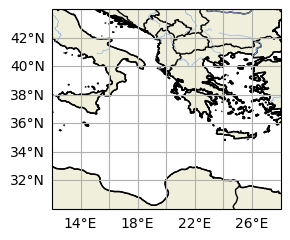

In [10]:
fig = plt.figure(figsize=(10,10)) 
ax = fig.add_axes([0.5, 1, 0.3, 0.2], projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, zorder=1, edgecolor='k')
ax.add_feature(cfeature.RIVERS, linewidth=0.5)
    
gl = ax.gridlines(draw_labels=True)
gl.right_labels = False
gl.top_labels = False

# Customize mini map
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='k')                  # add land mask
ax.set_extent([12, 28, 30, 44], crs = ccrs.PlateCarree())               # define the extent of the mini map [lon_min,lon_max,lat_min,lat_max]


In [11]:
Range_of_regions = {"range" : [12, 28, 30, 44]}
List_dataset_index = ["0","1","2","3","4","bathy"]
ds_model_list = [ds_0, ds_1, ds_2, ds_3, ds_4, ds_bathy]

for i in range(len(List_dataset_index)):
    globals()[f"ds_{List_dataset_index[i]}_sel"] = ds_model_list[i].where(
    (ds_0.longitude >= Range_of_regions["range"][0]) & 
    (ds_0.longitude <= Range_of_regions["range"][1]) &
    (ds_0.latitude >= Range_of_regions["range"][2]) & 
    (ds_0.latitude <= Range_of_regions["range"][3]),
    drop=True
)
    
ds_0 = ds_0_sel
ds_1 = ds_1_sel
ds_2 = ds_2_sel
ds_3 = ds_3_sel
ds_4 = ds_4_sel
ds_bathy = ds_bathy_sel

Setting variables

In [12]:
# Setting variables from dataset

# Standard wave parameters : Hs, t01, t02, t0m1, fp, dir, spr, c_group, stepness, wavelength
# Model's parameters : Hs, t01, t02, t0m1, fp, dir, spr
# Additional parameters : c_group, stepness, wavelength

# lat-lon
lon = ds_0["longitude"]
lat = ds_0["latitude"]

# diff
diff_hs = ds_2["hs"][:,:,:]
diff_t01 = ds_2["t01"][:,:,:]
diff_spread = ds_2["spr"][:,:,:]
diff_wave_dir = ds_2["dir"][:,:,:]
diff_fp = ds_2["fp"][:,:,:]

# forcings
ucur = ds_3["ucur"][:,:,:]
vcur = ds_3["vcur"][:,:,:]
uwnd = ds_3["uwnd"][:,:,:]
vwnd = ds_3["vwnd"][:,:,:]

# no currents parameters
hs_no_cur = ds_1["hs"][:,:,:]
t01_no_cur = ds_1["t01"][:,:,:]
spread_no_cur = ds_1["spr"][:,:,:]
wave_dir_no_cur = ds_1["dir"][:,:,:]
fp_no_cur = ds_1["fp"][:,:,:]

# with currents parameters
wave_dir_with_cur = ds_4["dir"][:,:,:]
t01_with_cur = ds_4["t01"][:,:,:]
hs_with_cur = ds_4["hs"][:,:,:]

# Bathymetry
Bathymetry = ds_bathy["Bathymetry"][:,:]

Setting values & units of variables

In [13]:
# lat-lon
lon2d = lon.values
lat2d = lat.values

# diff
diff_hs2d = diff_hs.values * units("m")
diff_t012d = diff_t01.values * units("s")
diff_spread = diff_spread.values
diff_wave_dir2d = diff_wave_dir.values
diff_fp2d = diff_fp.values * units("1/s")

# forcings
ucur2d = ucur.values * units("m/s") 
vcur2d = vcur.values * units("m/s")
uwnd2d = uwnd.values * units("m/s")
vwnd2d = vwnd.values * units("m/s")

# no currents parameters
hs_no_cur = hs_no_cur.values * units("m")
t01_no_cur = t01_no_cur.values * units("s")
spread_no_cur = spread_no_cur.values
wave_dir_no_cur = wave_dir_no_cur.values
fp_no_cur = fp_no_cur.values * units("1/s")

# with currents parameters
wave_dir_with_cur = wave_dir_with_cur.values
t01_with_cur = t01_with_cur.values * units("s")
hs_with_cur = hs_with_cur.values * units("m")

# Bathymetry
Bathymetry = Bathymetry.values * units("m")

Additional parameters

In [14]:
wnd_speed = np.sqrt(uwnd2d**2 + vwnd2d**2) 
cur_speed = np.sqrt(ucur2d**2 + vcur2d**2)
g = 9.81 * units("m/s**2")
c_phase_with_cur=(g*t01_with_cur)/(2*np.pi)
c_group_with_cur=(g*t01_with_cur)/(4*np.pi)
c_phase_no_cur=(g*t01_no_cur)/(2*np.pi)
c_group_no_cur=(g*t01_no_cur)/(4*np.pi)
wavelength_with_cur=(g*(t01_with_cur**2))/(2*np.pi)
stepness_with_cur = hs_with_cur/wavelength_with_cur
wave_age_with_cur = c_phase_with_cur/wnd_speed

c:\Users\kosta\AppData\Local\Programs\Python\Python313\Lib\site-packages\pint\facets\plain\quantity.py:1029: RuntimeWarning: divide by zero encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


Transforming wind and currents direction with respect to the meteorological convection

In [15]:
wnd_dir = np.degrees(np.arctan2(vwnd, uwnd))
wnd_dir = (270 - wnd_dir) % 360
cur_dir = np.degrees(np.arctan2(vcur, ucur))
cur_dir = (270 - cur_dir) % 360

Computation of wave components from wave direction

In [16]:
# WaveWatch direction: degrees, FROM, clockwise from North
D = wave_dir_no_cur  # shape (time, lat, lon)

# FROM -> TO
D_to = (D + 180) % 360

# Meteorological -> mathematical (radians)
theta = np.deg2rad(90 - D_to)

# Unit direction vectors
u_group_no_cur = c_group_no_cur*np.cos(theta)
v_group_no_cur = c_group_no_cur*np.sin(theta)

Computation of relative angles

In [17]:
angle_bet_cur_wave =  cur_dir - wave_dir_no_cur
angle_bet_cur_wnd = cur_dir - wnd_dir
angle_bet_wave_wnd = wave_dir_no_cur - wnd_dir

Angle between currents and wind

In [18]:
rel_angle_cur_wnd = xr.where((wnd_dir < 180) & (angle_bet_cur_wnd <= 180), angle_bet_cur_wnd, xr.where(
    (wnd_dir < 180) & (angle_bet_cur_wnd > 180), angle_bet_cur_wnd - 360, xr.where(
        (wnd_dir > 180) & (angle_bet_cur_wnd >= -180), angle_bet_cur_wnd, xr.where(
            (wnd_dir > 180) & (angle_bet_cur_wnd < -180), 360 + angle_bet_cur_wnd, angle_bet_cur_wnd)
    ) 
))
np.nanmax(rel_angle_cur_wnd), np.nanmin(rel_angle_cur_wnd),np.shape(rel_angle_cur_wnd)

(np.float32(179.99707), np.float32(-179.99786), (1, 737, 598))

Angle between currents and waves

In [19]:
rel_angle_wave = xr.where((wave_dir_no_cur < 180) & (angle_bet_cur_wave <= 180), angle_bet_cur_wave, xr.where(
    (wave_dir_no_cur < 180) & (angle_bet_cur_wave > 180), angle_bet_cur_wave - 360, xr.where(
        (wave_dir_no_cur > 180) & (angle_bet_cur_wave >= -180), angle_bet_cur_wave, xr.where(
            (wave_dir_no_cur > 180) & (angle_bet_cur_wave < -180), 360 + angle_bet_cur_wave, angle_bet_cur_wave)
    ) 
))
np.nanmax(rel_angle_wave), np.nanmin(rel_angle_wave),np.shape(rel_angle_wave)

(np.float32(179.99829), np.float32(-179.99973), (1, 737, 598))

Angle between wave and wind

In [20]:
rel_bet_wave_wnd = xr.where((wnd_dir < 180) & (angle_bet_wave_wnd <= 180), angle_bet_wave_wnd, xr.where(
    (wnd_dir < 180) & (angle_bet_wave_wnd > 180), angle_bet_wave_wnd - 360, xr.where(
        (wnd_dir > 180) & (angle_bet_wave_wnd >= -180), angle_bet_wave_wnd, xr.where(
            (wnd_dir > 180) & (angle_bet_wave_wnd < -180), 360 + angle_bet_wave_wnd, angle_bet_wave_wnd)
    ) 
))
np.nanmax(rel_bet_wave_wnd), np.nanmin(rel_bet_wave_wnd),np.shape(rel_bet_wave_wnd)

(np.float32(179.9864), np.float32(-179.99593), (1, 737, 598))

Wind input angle

In [21]:
u_input = uwnd - ucur
v_input = vwnd - vcur

input_angle = np.degrees(np.arctan2(v_input, u_input))
input_angle = (270 - input_angle) % 360

np.shape(input_angle), np.shape(v_input), np.shape(u_input), np.nanmax(input_angle), np.nanmin(input_angle), np.nanmean(input_angle), np.nanmax(v_input), np.nanmin(v_input), np.nanmax(u_input), np.nanmin(u_input)

((1, 737, 598),
 (1, 737, 598),
 (1, 737, 598),
 np.float32(359.9991),
 np.float32(0.0005187988),
 np.float32(233.10205),
 np.float32(13.5179405),
 np.float32(-14.803172),
 np.float32(14.605293),
 np.float32(-13.01614))

Angle between input and wnd

In [22]:
angle_bet_input_wnd = input_angle - wnd_dir
rel_bet_input_wnd = xr.where((wnd_dir < 180) & (angle_bet_input_wnd <= 180), angle_bet_input_wnd, xr.where(
    (wnd_dir < 180) & (angle_bet_input_wnd > 180), angle_bet_input_wnd - 360, xr.where(
        (wnd_dir > 180) & (angle_bet_input_wnd >= -180), angle_bet_input_wnd, xr.where(
            (wnd_dir > 180) & (angle_bet_input_wnd < -180), 360 + angle_bet_input_wnd, angle_bet_input_wnd)
    ) 
))
np.nanmax(rel_bet_input_wnd), np.nanmin(rel_bet_input_wnd),np.shape(rel_bet_input_wnd)

(np.float32(177.77686), np.float32(-175.77855), (1, 737, 598))

Compute gradients, divergence and vorticity

In [23]:
# Compute grid spacing in meters
dx_g, dy_g = mpcalc.lat_lon_grid_deltas(lon2d, lat2d)
dx_g, dy_g

(<Quantity([[2670.14149731 2669.14316982 2669.23368767 ... 2670.60712753
   2671.33958737 2671.53204413]
  [2668.50649027 2668.59459412 2668.50650902 ... 2669.80843946
   2670.90617814 2669.99836451]
  [2667.96225274 2667.86837855 2668.88667885 ... 2670.29167897
   2669.19578776 2669.37536093]
  ...
  [2203.44883838 2203.52082942 2203.47220229 ... 2221.9423188
   2221.26127406 2222.00911118]
  [2203.59749183 2202.81017801 2202.92234214 ... 2220.53315765
   2221.59741649 2220.53853355]
  [2203.04760504 2202.13961209 2202.37322809 ... 2220.20019733
   2220.90218711 2220.20593613]], 'meter')>,
 <Quantity([[2598.75239009 2597.47411165 2598.53504124 ... 2533.00545377
   2533.00656264 2533.00115182]
  [2597.4740926  2597.68668556 2597.68617696 ... 2531.95305453
   2530.88570634 2531.9461238 ]
  [2596.41365296 2596.41365307 2596.41942661 ... 2530.8845759
   2530.88568469 2529.61892936]
  ...
  [1957.8620268  1957.01805931 1955.75182615 ... 1695.27097583
   1695.7096776  1695.28859124]
  [1955

In [24]:
t,x,y = np.shape(diff_hs2d)[0], np.shape(diff_hs2d)[1], np.shape(diff_hs2d)[2]
t,x,y

(1, 737, 598)

In [25]:
div = np.zeros((t,x,y))
vor = np.zeros((t,x,y))
normal_vor = np.zeros((t,x,y))
f = np.zeros((x,y))
omega = 7.2921*(10**(-5))

d = mpcalc.divergence(ucur2d[0],vcur2d[0],dx=dx_g,dy=dy_g)
v = mpcalc.vorticity(ucur2d[0],vcur2d[0],dx=dx_g,dy=dy_g)
f = 2*omega*np.sin(np.deg2rad(lat2d))

div = d
vor = v
normal_vor = (v)/(f)

np.shape(normal_vor), np.shape(div), np.shape(vor), np.nanmean(f), np.nanmax(f), np.nanmin(f)

((737, 598),
 (737, 598),
 (737, 598),
 np.float32(8.9135494e-05),
 np.float32(0.00010341905),
 np.float32(7.322398e-05))

Masking nan values

In [26]:
div_masked = np.ma.masked_invalid(div)
normal_vor_masked = np.ma.masked_invalid(normal_vor)
vor_masked = np.ma.masked_invalid(vor) 

Range fuction (for norms and levels in plots)

In [27]:
import numpy as np
from scipy.stats import skew, kurtosis, normaltest

def adaptive_percentile_range(data):
    """
    Compute an adaptive percentile range for plotting, 
    depending on the data distribution.
    
    Returns (lower_bound, upper_bound, coverage_percent).
    """
    data = np.asarray(data)
    data = data[np.isfinite(data)]  # remove NaNs and infs

    # Basic distribution metrics
    s = skew(data)
    k = kurtosis(data)
    stat, pval = normaltest(data)  # normality test (null: normal)

    # Start with default 95% range
    coverage = 95.0
    
    # Adjust for heavy tails or skewed data
    if pval < 0.05:  # not normal
        if abs(s) > 1 or k > 3:       # strongly skewed or heavy tails
            coverage = 90.0
        elif abs(s) > 0.5 or k > 1:   # moderately skewed
            coverage = 93.0
    else:
        coverage = 98.0  # almost normal, show more of the data

    lower = (100 - coverage) / 2
    upper = 100 - lower
    bounds = np.percentile(data, [lower, upper])

    return bounds, coverage


Plots style

In [28]:
def style_axis(ax, title=None, cbar=None, cbar_tick_fontsize=44):
    """Apply consistent map style and optional title to an axis."""
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, zorder=1, edgecolor='k')
    ax.add_feature(cfeature.RIVERS, linewidth=0.5)

    # define the extent of the mini map [lon_min,lon_max,lat_min,lat_max]
    ax.set_extent([Range_of_regions["range"][0], Range_of_regions["range"][1], 
                Range_of_regions["range"][2], Range_of_regions["range"][3]], 
                crs = ccrs.PlateCarree()) 
    
    gl = ax.gridlines(draw_labels=True, alpha = 0)
    gl.right_labels = False
    gl.top_labels = False

    # Set font size for lat/lon labels
    gl.xlabel_style = {'size': 40}
    gl.ylabel_style = {'size': 40}

    if cbar is not None:
        cbar.ax.tick_params(labelsize=cbar_tick_fontsize)  # numbers
    
    if title:
        ax.set_title(title, fontsize=50, weight='bold')
        #ax.set_title(title, fontsize=50)
    return ax

In [29]:
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap

# Blue gradient for -90 to 90
blue_cmap = LinearSegmentedColormap.from_list(
    "blue_range", ["#d0e4ff", "#0033cc"]   # light blue → dark blue
)

# For the center region (blue): light → dark
blue_left = blue_cmap(np.linspace(1, 0, 128))
blue_right = blue_cmap(np.linspace(0, 1, 128))

# Red gradient that always goes: light → dark
# (so we can reverse it when needed)
red_base = LinearSegmentedColormap.from_list(
    "red_range_base", ["#ffcccc", "#cc0000"]
)

# For the left red region (-180 → -90): dark → light
red_left = red_base(np.linspace(1, 0, 128))  # reversed

# For the right red region (90 → 180): light → dark
red_right = red_base(np.linspace(0, 1, 128))  # normal direction

# Combine:
combined_colors = np.vstack([red_left, blue_left, blue_right, red_right])
combined_cmap = ListedColormap(combined_colors)

Forcing plots (wind & surface currents fields)

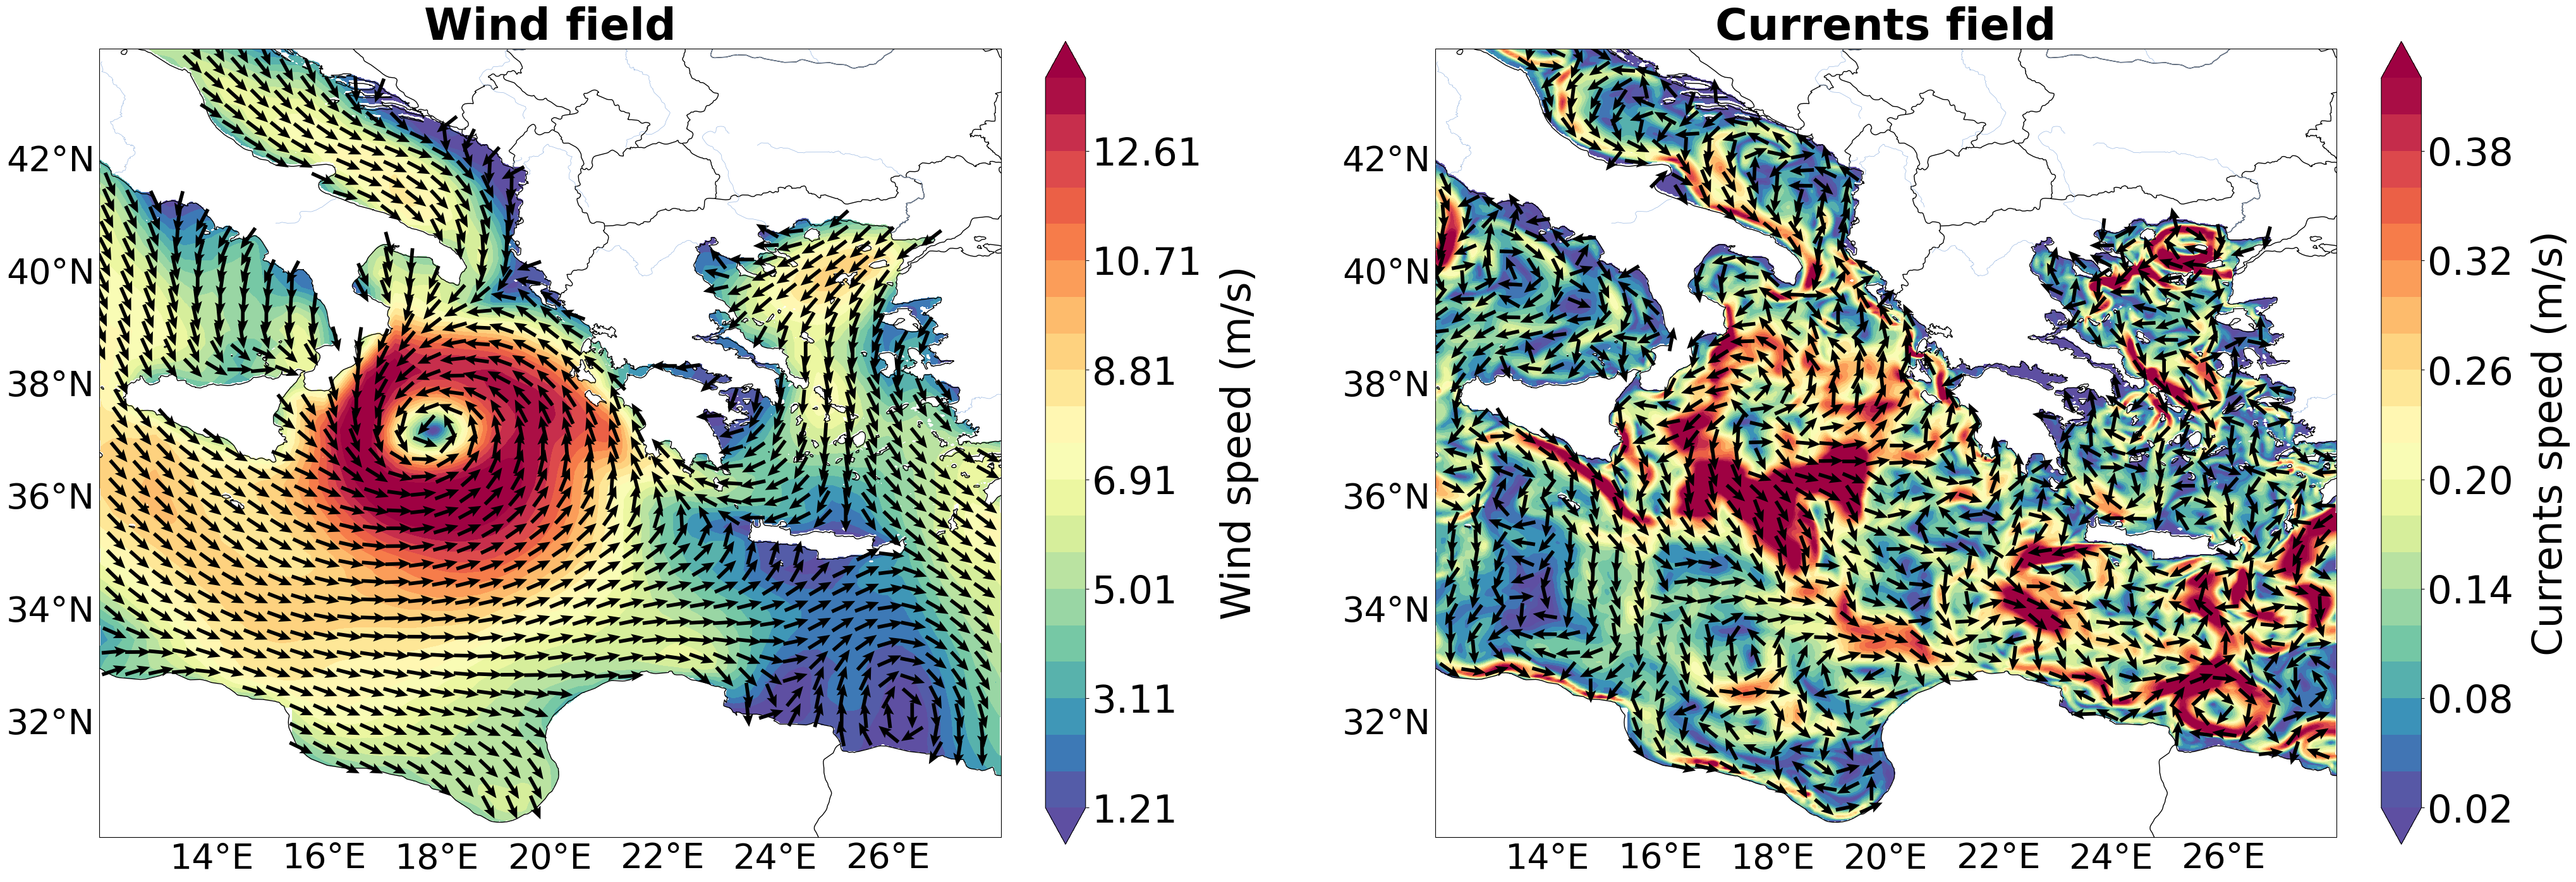

In [30]:
from matplotlib.patches import Rectangle

List_seasons = ["29/01, 01:00","31/01, 06:00", "AMJ", "JAS", "OND"]

List_parameters = [hs_no_cur, 100*diff_hs2d, cur_speed]

List_var = ["SWH (m)", "SWH (cm)", "currents speed (m/s)"]
List_colorbar = ["Spectral_r", "coolwarm", "Spectral_r"]

List_format_var = [2,2,3]
List_format_diff = [2,3,2]


for j in range(0,1):
    fig, axes = plt.subplots(1, 2, figsize=(50, 30), 
    subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()  # flatten to a 1D array of length 10
    ax1, ax2 = axes

    #fig.suptitle(f'Wind and currents forcings - {Region_plots}', x=0.45,y=0.92, 
    #            ha='center',fontsize = 26)
    #plt.rcParams.update({"axes.titlesize": 24,"axes.labelsize": 24})
    plt.subplots_adjust(wspace=0.2)  # increase vertical spacing
    CBAR_SHRINK = 0.55

    step = 21
    bounds_wnd_speed,_ = adaptive_percentile_range(wnd_speed[j])
    min_wnd_speed, max_wnd_speed = bounds_wnd_speed
    # Define normalization
    norm_1 = mcolors.Normalize(vmin=min_wnd_speed, vmax=max_wnd_speed)
    levels_1 = np.round(np.linspace(min_wnd_speed, max_wnd_speed, step), 
                        2)
    levels_1 = np.unique(levels_1)
    cf = ax1.contourf(ds_0_sel.longitude, ds_0_sel.latitude, wnd_speed[j],
                    transform=ccrs.PlateCarree(),
                    levels=levels_1,
                    norm=norm_1, extend="both", cmap="Spectral_r")
    cbar = fig.colorbar(cf, pad=0.04, ax=ax1, label="Wind speed (m/s)",
    shrink=CBAR_SHRINK)

    step_norm = 15
    U_norm_wnd = np.sqrt(ds_3_sel["uwnd"][j,::step_norm,::step_norm]**2 + ds_3_sel["vwnd"][j,::step_norm,::step_norm]**2)
    U_wnd = ds_3_sel["uwnd"][j, ::step_norm, ::step_norm]/U_norm_wnd
    V_wnd = ds_3_sel["vwnd"][j, ::step_norm, ::step_norm]/U_norm_wnd
    X = ds_0_sel.longitude[::step_norm,::step_norm]
    Y = ds_0_sel.latitude[::step_norm,::step_norm]

    ax1.quiver(X, Y, U_wnd, V_wnd, transform=ccrs.PlateCarree(), pivot = 'mid', 
               width = 0.004, 
                scale_units='xy', scale=2.2, angles='xy',
                headlength = 3.5, headaxislength = 3.0)
    cbar.set_label(label="Wind speed (m/s)", size=46, labelpad=20)
    style_axis(ax1, f"Wind field", cbar=cbar, cbar_tick_fontsize=44)

    bounds_cur_speed,_ = adaptive_percentile_range(cur_speed[j])
    min_cur_speed, max_cur_speed = bounds_cur_speed
    # Define normalization
    norm_2 = mcolors.Normalize(vmin=min_cur_speed, vmax=max_cur_speed)
    levels_2 = np.round(np.linspace(min_cur_speed, max_cur_speed, step), 
                        2)
    levels_2 = np.unique(levels_2)
    cf = ax2.contourf(ds_0_sel.longitude, ds_0_sel.latitude, cur_speed[j],
                    transform=ccrs.PlateCarree(),
                    levels=levels_2,
                    norm=norm_2, extend="both", cmap="Spectral_r")
    cbar = fig.colorbar(cf, pad=0.04, ax=ax2, label="Currents speed (m/s)",
    shrink=CBAR_SHRINK)

    step_norm = 15
    U_norm_cur = np.sqrt(ds_3_sel["ucur"][j,::step_norm,::step_norm]**2 + ds_3_sel["vcur"][j,::step_norm,::step_norm]**2)
    U_cur = ds_3_sel["ucur"][j, ::step_norm, ::step_norm] / U_norm_cur
    V_cur = ds_3_sel["vcur"][j, ::step_norm, ::step_norm] / U_norm_cur
    X = ds_0_sel.longitude[::step_norm,::step_norm]
    Y = ds_0_sel.latitude[::step_norm,::step_norm]

    ax2.quiver(X, Y, U_cur, V_cur, transform=ccrs.PlateCarree(), pivot='mid', 
               width = 0.004,
                scale_units='xy', scale=2.3, angles='xy', headlength = 3.5,
                headaxislength = 3)
    cbar.set_label(label="Currents speed (m/s)", size=46, labelpad=20)
    style_axis(ax2, "Currents field", cbar=cbar, cbar_tick_fontsize=44)

Complex analysis plots

'# Define the full path for the file, including the non-existent directory\noutput_file = f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Complex analysis (relative angle & vorticity)//SWH//{Phenom_period[period]}.png"\n\n# Extract the directory path from the file path\ndirectory = os.path.dirname(output_file)\n\n# Create the directory if it does not exist, including any intermediate directories\nif not os.path.exists(directory):\n    os.makedirs(directory, exist_ok=True) # exist_ok=True prevents error if dir already exists\n\nfig.savefig(output_file)'

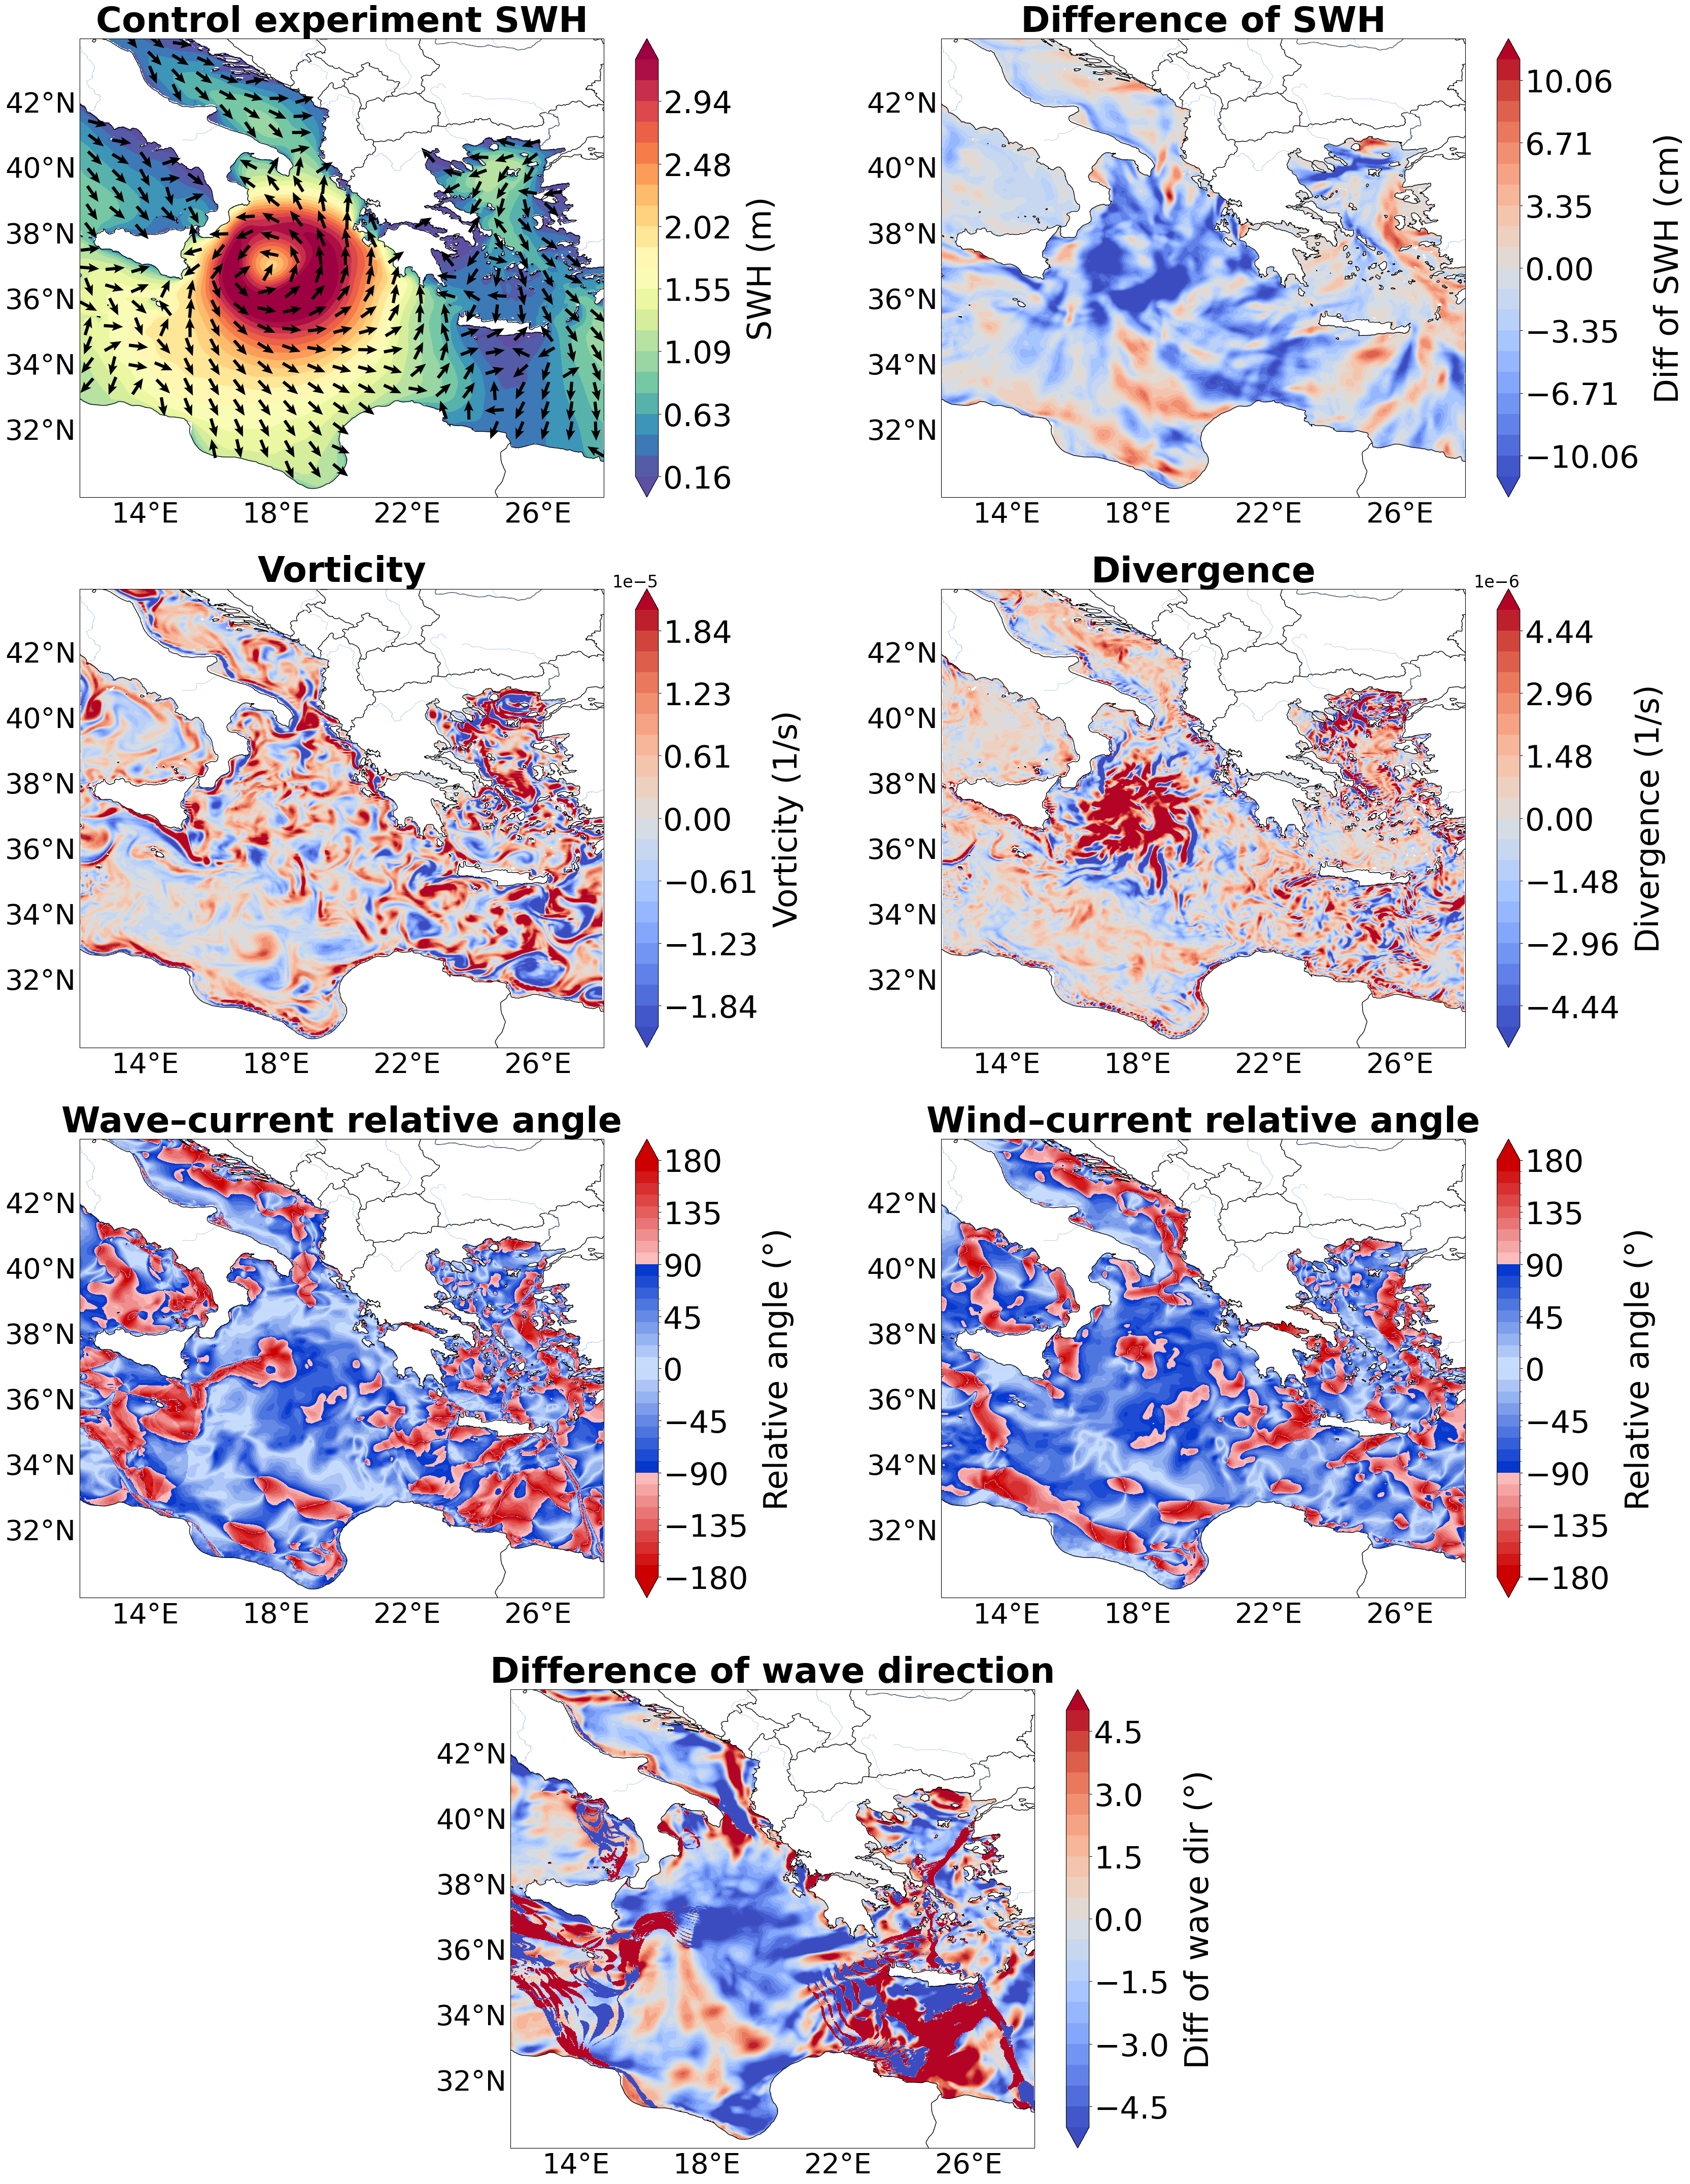

In [30]:
import os
from matplotlib.colors import TwoSlopeNorm

Phenom_period = ["Formation","Intense period","Dissipitation"]
period = 1
format_bounds = [2,2,2]


mosaic = """
AABB
CCDD
EEFF
.GG."""

fig, ax_dict = plt.subplot_mosaic(
    mosaic,
    figsize=(42, 54),
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'height_ratios': [1, 1, 1, 1],
    },sharey=True
)

# Assign axis variables
ax1 = ax_dict["A"]
ax2 = ax_dict["B"]
ax3 = ax_dict["C"]
ax4 = ax_dict["D"]
ax5 = ax_dict["E"]
ax6 = ax_dict["F"]
ax7 = ax_dict["G"]

#fig.suptitle(f'{Phenom_period[period]}', x=0.5,y=0.92, 
#            ha='center',fontsize = 22)
#plt.rcParams.update({"axes.titlesize": 20,"axes.labelsize": 20})
#plt.subplots_adjust(hspace=0.2, wspace=0.1)  # increase vertical spacing
plt.subplots_adjust(hspace=0.2)
CBAR_SHRINK = 1.0
j=0

step = 21
bounds_hs_no_cur,_ = adaptive_percentile_range(hs_no_cur[0])
min_hs_no_cur, max_hs_no_cur = bounds_hs_no_cur
# Define normalization
norm_1 = mcolors.Normalize(vmin=min_hs_no_cur, vmax=max_hs_no_cur)
levels_1 = np.round(np.linspace(min_hs_no_cur, max_hs_no_cur, step), 
                    format_bounds[0])
levels_1 = np.unique(levels_1)
cf = ax1.contourf(ds_0.longitude,ds_0.latitude,hs_no_cur[0], 
                transform=ccrs.PlateCarree(), 
                levels=levels_1,
                norm=norm_1, extend = "both",cmap="Spectral_r")
cbar = fig.colorbar(cf,pad=0.04,ax =ax1,label="SWH (m)", 
                    shrink=CBAR_SHRINK)
cbar.set_label(label="SWH (m)", size=46, labelpad=20)
style_axis(ax1, title="Control experiment SWH", cbar=cbar, cbar_tick_fontsize=44)

#step_norm = 15
step_norm = 28
U_norm_group_with_cur = c_group_no_cur[j, ::step_norm, ::step_norm]
U_group_with_cur = u_group_no_cur[j, ::step_norm, ::step_norm] / U_norm_group_with_cur
V_group_with_cur = v_group_no_cur[j, ::step_norm, ::step_norm] / U_norm_group_with_cur
X, Y = lon2d[::step_norm, ::step_norm], lat2d[::step_norm, ::step_norm]

"""ax1.quiver(X, Y, U_group_with_cur, V_group_with_cur, transform=ccrs.PlateCarree(),
            pivot = 'mid', width = 0.004, 
            scale_units='xy', scale=2.3, angles='xy',
            headlength = 3.5, headaxislength = 3.0)"""

ax1.quiver(X, Y, U_group_with_cur, V_group_with_cur, transform=ccrs.PlateCarree(),
            pivot = 'mid', width = 0.006, 
            scale_units='xy', scale=1.7, angles='xy',
            headlength = 3.5, headaxislength = 3.0)

bounds_diff_hs,_ = adaptive_percentile_range(diff_hs2d[0])
min_diff_hs, max_diff_hs = 100*bounds_diff_hs
# symmetric range
abs_max = max(abs(min_diff_hs), abs(max_diff_hs))

# choose normalization automatically
if min_diff_hs < 0 and max_diff_hs > 0:
    # mixed values → use diverging normalization centered at 0
    norm_2 = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
else:
    # only positive or only negative → use standard normalization
    norm_2 = mcolors.Normalize(vmin=min_diff_hs, vmax=max_diff_hs)
levels_2 = np.round(np.linspace(-abs_max, abs_max, step), 
                    format_bounds[0])
levels_2 = np.unique(levels_2)
cf = ax2.contourf(ds_0.longitude,ds_0.latitude,100*diff_hs2d[0], 
                transform=ccrs.PlateCarree(), 
                levels=levels_2,
                norm=norm_2, extend = "both",cmap="coolwarm")
cbar = fig.colorbar(cf,pad=0.04,ax =ax2,label="Diff of SWH (cm)",
                    shrink=CBAR_SHRINK)
cbar.set_label(label="Diff of SWH (cm)", size=46, labelpad=20)
style_axis(ax2, title="Difference of SWH", cbar=cbar, cbar_tick_fontsize=44)

angle_bounds = np.linspace(-180, 180, 37)
angle_norm = BoundaryNorm(angle_bounds, combined_cmap.N)
ticks = [-180, -135, -90, -45, 0, 45, 90, 135, 180]

cf = ax5.contourf(ds_0_sel.longitude,ds_0_sel.latitude,rel_angle_wave[j], 
                transform=ccrs.PlateCarree(), 
                levels=angle_bounds,
                norm=angle_norm, extend = "both",cmap=combined_cmap)
cbar = fig.colorbar(cf,pad=0.04,ax =ax5,label="Relative angle (°)",
                    shrink=CBAR_SHRINK, ticks=ticks)
cbar.set_label(label="Relative angle (°)", size=46, labelpad=20)
style_axis(ax5, title="Wave–current relative angle", cbar=cbar, 
            cbar_tick_fontsize=44)

angle_bounds = np.linspace(-180, 180, 37)
angle_norm = BoundaryNorm(angle_bounds, combined_cmap.N)
ticks = [-180, -135, -90, -45, 0, 45, 90, 135, 180]

cf = ax6.contourf(ds_0_sel.longitude,ds_0_sel.latitude,rel_angle_cur_wnd[j], 
                transform=ccrs.PlateCarree(), 
                levels=angle_bounds,
                norm=angle_norm, extend = "both",cmap=combined_cmap)
cbar = fig.colorbar(cf,pad=0.04,ax =ax6,label="Relative angle (°)",
                    shrink=CBAR_SHRINK, ticks=ticks)
cbar.set_label(label="Relative angle (°)", size=46, labelpad=20)
style_axis(ax6, title="Wind–current relative angle", 
           cbar=cbar, cbar_tick_fontsize=44)

bounds_vor,_ = adaptive_percentile_range(vor_masked)
min_vor, max_vor = bounds_vor
# symmetric range
abs_max = max(abs(min_vor), abs(max_vor))
# Define normalization
norm_5 = mcolors.Normalize(vmin=-abs_max, vmax=abs_max)
levels_5 = np.round(np.linspace(-abs_max, abs_max, step), 
                    7)
levels_5 = np.unique(levels_5)
cf = ax3.contourf(ds_0.longitude,ds_0.latitude,vor_masked, 
                transform=ccrs.PlateCarree(), 
                levels=levels_5,
                norm=norm_5, extend = "both",cmap="coolwarm")
cbar = fig.colorbar(cf,pad=0.04,ax =ax3,label="Vorticity (1/s)",
                    shrink=CBAR_SHRINK)
cbar.set_label(label="Vorticity (1/s)", size=46, labelpad=20)
cbar.ax.yaxis.get_offset_text().set_fontsize(24) 
style_axis(ax3, title="Vorticity", cbar=cbar, cbar_tick_fontsize=44)

bounds_step,_ = adaptive_percentile_range(div_masked)
min_step, max_step = bounds_step
# symmetric range
abs_max = max(abs(min_step), abs(max_step))

# Define normalization
norm_6 = mcolors.Normalize(vmin=-abs_max, vmax=abs_max)
levels_6 = np.round(np.linspace(-abs_max, abs_max, step), 
                    8)
levels_6 = np.unique(levels_6)
cf = ax4.contourf(ds_0.longitude,ds_0.latitude,div_masked, 
                transform=ccrs.PlateCarree(), 
                levels=levels_6,
                norm=norm_6, extend = "both",cmap="coolwarm")
cbar = fig.colorbar(cf,pad=0.04,ax =ax4,label="Divergence (1/s)",
                    shrink=CBAR_SHRINK)
cbar.set_label(label="Divergence (1/s)", size=46, labelpad=20)
cbar.ax.yaxis.get_offset_text().set_fontsize(24)
style_axis(ax4, title="Divergence", cbar=cbar, cbar_tick_fontsize=44)

bounds_diff_wave_dir,_ = adaptive_percentile_range(diff_wave_dir2d[j])
min_diff_wave_dir, max_diff_wave_dir = bounds_diff_wave_dir
# symmetric range
abs_max = max(abs(min_diff_wave_dir), abs(max_diff_wave_dir))
abs_max = 5

# choose normalization automatically
if min_diff_wave_dir < 0 and max_diff_wave_dir > 0:
    # mixed values → use diverging normalization centered at 0
    norm_7 = TwoSlopeNorm(vmin=-abs_max, vcenter=0, 
                            vmax=abs_max)
else:
    # only positive or only negative → use standard normalization
    norm_7 = mcolors.Normalize(vmin=min_diff_wave_dir, 
                                vmax=max_diff_wave_dir)
levels_7 = np.round(np.linspace(-abs_max, abs_max, step), 
                    format_bounds[0])
levels_7 = np.unique(levels_7)
cf = ax7.contourf(ds_0_sel.longitude,ds_0_sel.latitude,diff_wave_dir2d[j], 
                transform=ccrs.PlateCarree(), 
                levels=levels_7,
                norm=norm_7, extend = "both",cmap="coolwarm")
cbar = fig.colorbar(cf,pad=0.04,ax =ax7,label="Diff of wave dir (°)",
                    shrink=CBAR_SHRINK)
cbar.set_label(label="Diff of wave dir (°)", size=46, labelpad=20)
style_axis(ax7, title="Difference of wave direction", cbar=cbar, 
           cbar_tick_fontsize=44)    

"""# Define the full path for the file, including the non-existent directory
output_file = f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Complex analysis (relative angle & vorticity)//SWH//{Phenom_period[period]}.png"

# Extract the directory path from the file path
directory = os.path.dirname(output_file)

# Create the directory if it does not exist, including any intermediate directories
if not os.path.exists(directory):
    os.makedirs(directory, exist_ok=True) # exist_ok=True prevents error if dir already exists

fig.savefig(output_file)"""